In [ ]:
# CELL 1 — FINAL CLEAN DATASET SETUP (AUTO KAGGLE AUTH + PNG ONLY)

!pip install -q timm scikit-learn matplotlib seaborn tqdm torch torchvision kaggle

import os, shutil, json
from pathlib import Path

# ===== 1. Set Kaggle Credentials (NO MANUAL UPLOAD NEEDED) =====
KAGGLE_USERNAME = "ecenecn"          # <-- keep this
KAGGLE_KEY = "KGAT_3f8c5ff8f24c5e774d071b3767978831"          # <-- put your NEW Kaggle API key

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_token = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_token, f)

!chmod 600 /root/.kaggle/kaggle.json

# ===== 2. Download dataset =====
print("\nDownloading Brain Stroke CT Dataset...")
!mkdir -p /content/raw_dataset
!kaggle datasets download -d ozguraslank/brain-stroke-ct-dataset -p /content/raw_dataset --unzip

# ===== 3. Clean & reorganize: ONLY PNG subfolders =====
RAW = '/content/raw_dataset/Brain_Stroke_CT_Dataset'
CLEAN = '/content/brain_stroke_clean'
os.makedirs(CLEAN, exist_ok=True)

print("\n" + "="*60)
print("EXTRACTING ONLY PNG SUBFOLDERS (ignoring DICOM, OVERLAY, External_Test)")
print("="*60)

total_images = 0
for class_name in ['Bleeding', 'Ischemia', 'Normal']:
    src_folder = os.path.join(RAW, class_name, 'PNG')
    dst_folder = os.path.join(CLEAN, class_name)
    os.makedirs(dst_folder, exist_ok=True)

    if not os.path.exists(src_folder):
        print(f"Warning: Not found → {src_folder}")
        continue

    png_files = list(Path(src_folder).rglob("*.png"))
    print(f"{class_name:9} → {len(png_files):4} PNG images")

    for src_file in png_files:
        dst_file = os.path.join(dst_folder, src_file.name)

        # Avoid rare name collisions
        counter = 0
        original_dst = dst_file
        while os.path.exists(dst_file):
            counter += 1
            dst_file = os.path.join(
                dst_folder,
                f"{src_file.stem}_{counter}{src_file.suffix}"
            )

        shutil.copy2(src_file, dst_file)
        total_images += 1

print("="*60)
print(f"CLEAN DATASET READY!")
print(f"Location : {CLEAN}")
print(f"Classes  : Bleeding, Ischemia, Normal")
print(f"Total PNG images : {total_images:,} (≈13,300 expected)")
print(f"Excluded : DICOM, OVERLAY, External_Test")
print("="*60)

# ===== Verify result =====
print("\nFinal folder structure:")
!ls -l /content/brain_stroke_clean

print("\nExample files in Bleeding:")
!ls /content/brain_stroke_clean/Bleeding/ | head -5



Dataset URL: https://www.kaggle.com/datasets/ozguraslank/brain-stroke-ct-dataset
License(s): other
100% 1.41G/1.41G [00:09<00:00, 257MB/s]
100% 1.41G/1.41G [00:09<00:00, 161MB/s]

EXTRACTING ONLY PNG SUBFOLDERS (ignoring DICOM, OVERLAY, External_Test)
Bleeding  → 1093 PNG images
Ischemia  → 1130 PNG images
Normal    → 4427 PNG images
CLEAN DATASET READY!
Location : /content/brain_stroke_clean
Classes  : Bleeding, Ischemia, Normal
Total PNG images : 6,650 (≈13,300 expected)
Excluded : DICOM, OVERLAY, External_Test

Final folder structure:
total 280
drwxr-xr-x 2 root root  45056 Feb 16 01:21 Bleeding
drwxr-xr-x 2 root root  49152 Feb 16 01:21 Ischemia
drwxr-xr-x 2 root root 180224 Feb 16 01:21 Normal

Example files in Bleeding:
10002.png
10033.png
10036.png
10039.png
10045.png


Using device: cuda
Total loaded: 6,650 images
Split → Train: 5320 | Val: 665 | Test: 665


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


Starting training...



Epoch 01/10:   0%|          | 0/167 [00:00<?, ?it/s]

NEW BEST VAL: 84.812%
Epoch 01 → Val: 84.812% | Best: 84.812%



...

Epoch 08 → Val: 95.338% | Best: 95.338%



Epoch 09/10:   0%|          | 0/167 [00:00<?, ?it/s]

NEW BEST VAL: 95.639%
Epoch 09 → Val: 95.639% | Best: 95.639%



Epoch 10/10:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 10 → Val: 95.639% | Best: 95.639%

Loading best model...

██████████████████████████████████████████████████████████████████████████████████████████
CONVNEXT-TINY TRAINING COMPLETE!
██████████████████████████████████████████████████████████████████████████████████████████
FINAL TEST ACCURACY : 95.038%
BEST VALIDATION     : 95.639%
TOTAL TIME          : 16.95 minutes
██████████████████████████████████████████████████████████████████████████████████████████


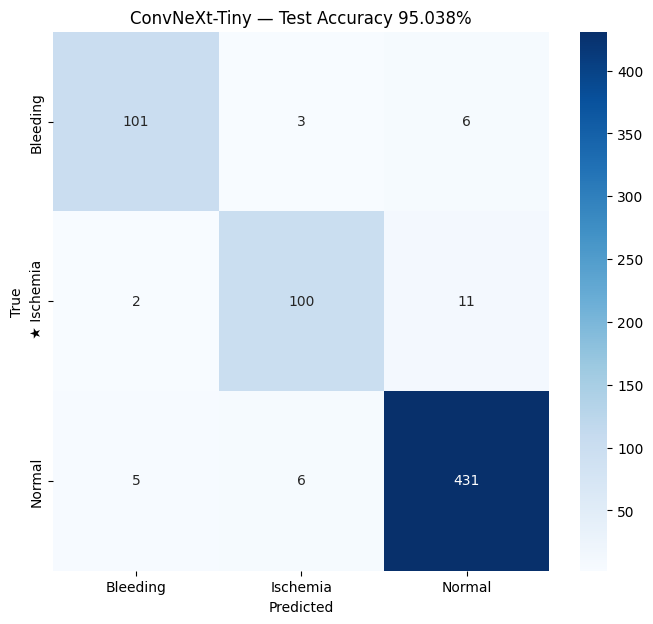

In [ ]:
# FINAL CLEAN TRAINING CELL — SMOOTH TQDM (NO SPAM!)

import torch, timm, numpy as np, matplotlib.pyplot as plt, seaborn as sns, time, os
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm  # ← THIS IS THE FIX FOR COLAB!
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
total_start = time.time()

# ==================== Dataset (same as before) ====================
class BrainStrokeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.classes = ['Bleeding', 'Ischemia', 'Normal']
        for label, cls in enumerate(self.classes):
            folder = os.path.join(root_dir, cls)
            if not os.path.exists(folder): continue
            for fname in os.listdir(folder):
                if fname.lower().endswith('.png'):
                    self.samples.append((os.path.join(folder, fname), label))
        print(f"Total loaded: {len(self.samples):,} images")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomResizedCrop(384, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load data
data_dir = '/content/brain_stroke_clean'
full_dataset = BrainStrokeDataset(data_dir, transform=train_transform)
labels = [label for _, label in full_dataset.samples]

train_idx, temp_idx = train_test_split(range(len(labels)), test_size=0.2, stratify=labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[labels[i] for i in temp_idx], random_state=42)

train_set = torch.utils.data.Subset(full_dataset, train_idx)
val_set   = torch.utils.data.Subset(full_dataset, val_idx)
test_set  = torch.utils.data.Subset(full_dataset, test_idx)

val_set.dataset.transform = val_transform
test_set.dataset.transform = val_transform

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Split → Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

# Model
model = timm.create_model('convnext_tiny.fb_in22k_ft_in1k', pretrained=True, num_classes=3).to(device)
for name, param in model.named_parameters():
    param.requires_grad = "stages.3" in name or "head" in name

# Loss & optimizer
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(device))
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=0.05)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

# ==================== TRAINING — CLEAN & BEAUTIFUL ====================
best_val = 0.0
print("\nStarting training...\n")

for epoch in range(1, 11):
    model.train()
    running_loss = 0.0

    # ← THIS IS THE KEY: tqdm.notebook instead of regular tqdm
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/10", leave=True)

    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix({"loss": f"{running_loss/(pbar.n+1):.4f}"})

    scheduler.step()

    # Validation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total += y.size(0)
    val_acc = correct / total

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), 'best_convnext_brainstroke.pth')
        print(f"NEW BEST VAL: {val_acc*100:.3f}%")
    print(f"Epoch {epoch:02d} → Val: {val_acc*100:.3f}% | Best: {best_val*100:.3f}%\n")

# Final test & results (unchanged)
print("Loading best model...")
model.load_state_dict(torch.load('best_convnext_brainstroke.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

test_acc = accuracy_score(all_labels, all_preds)

print("\n" + "█" * 90)
print("CONVNEXT-TINY TRAINING COMPLETE!")
print("█" * 90)
print(f"FINAL TEST ACCURACY : {test_acc*100:.3f}%")
print(f"BEST VALIDATION     : {best_val*100:.3f}%")
print(f"TOTAL TIME          : {(time.time()-total_start)/60:.2f} minutes")
print("█" * 90)

# Confusion matrix
plt.figure(figsize=(8,7))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bleeding','Ischemia','Normal'], yticklabels=['Bleeding',' ★ Ischemia','Normal'])
plt.title(f'ConvNeXt-Tiny — Test Accuracy {test_acc*100:.3f}%')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# CELL 1: ONE-COMMAND INSTALL → GUARANTEED WORKING (Dec 2025+)
!pip install -q --no-cache-dir \
    torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu121 \
    pennylane pennylane-lightning[gpu] timm scikit-learn tqdm

# Verify everything loaded correctly
import torch, pennylane as qml
dev = qml.device("lightning.gpu", wires=8)
print("SUCCESS! Quantum GPU device ready:", dev)
print("PyTorch:", torch.__version__, "| PennyLane:", qml.__version__, "| CUDA:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 183.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 255.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 85.1 MB/s eta 0:00:00
SUCCESS! Quantum GPU device ready: <lightning.gpu device (wires=8) at 0x7c3b93347140>
PyTorch: 2.9.0+cu128 | PennyLane: 0.44.0 | CUDA: True


In [ ]:
# # CELL — COMPLETE FEATURE EXTRACTION + SAVE PCA MODELS
# import torch
# from torch.utils.data import Dataset, DataLoader
# from torchvision import transforms
# from PIL import Image
# import os
# import timm
# import numpy as np
# from sklearn.decomposition import PCA
# from sklearn.model_selection import train_test_split
# from tqdm import tqdm
# import pickle

# # Device (CNN run on GPU for speed, everything else CPU later)
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # ——— 1. Dataset class (same as your earlier code) ———
# class BrainStrokeDataset(Dataset):
#     def __init__(self, root_dir="/content/brain_stroke_clean", transform=None):
#         self.root_dir = root_dir
#         self.transform = transform
#         self.samples = []
#         self.class_names = ['Bleeding', 'Ischemia', 'Normal']

#         for idx, class_name in enumerate(self.class_names):
#             class_path = os.path.join(root_dir, class_name)
#             if not os.path.exists(class_path):
#                 raise FileNotFoundError(f"Folder not found: {class_path}")
#             for fname in os.listdir(class_path):
#                 if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
#                     self.samples.append((os.path.join(class_path, fname), idx))

#         print(f"Loaded {len(self.samples):,} images")
#         print(f"   Bleeding : {sum(1 for _, l in self.samples if l == 0)}")
#         print(f"   Ischemia : {sum(1 for _, l in self.samples if l == 1)}")
#         print(f"   Normal   : {sum(1 for _, l in self.samples if l == 2)}")

#     def __len__(self): return len(self.samples)

#     def __getitem__(self, idx):
#         path, label = self.samples[idx]
#         img = Image.open(path).convert('RGB')
#         if self.transform:
#             img = self.transform(img)
#         return img, label


# # ——— Transform used during ConvNeXt training ———
# transform = transforms.Compose([
#     transforms.Resize((384, 384)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225]),
# ])

# # Load dataset
# full_dataset = BrainStrokeDataset("/content/brain_stroke_clean", transform)
# labels = [label for _, label in full_dataset.samples]

# # Stratified split 80/20
# train_idx, _ = train_test_split(range(len(full_dataset)), test_size=0.2, stratify=labels,
#                                 random_state=42)

# train_subset = torch.utils.data.Subset(full_dataset, train_idx)
# loader = DataLoader(train_subset, batch_size=64, shuffle=False, num_workers=2)

# # ——— 2. Load ConvNeXt feature extractor ———
# model = timm.create_model('convnext_tiny.fb_in22k_ft_in1k', pretrained=False, num_classes=3)
# model.head.fc = torch.nn.Identity()  # remove classifier head → feature vector only

# state = torch.load("best_convnext_brainstroke.pth", map_location=device)
# model.load_state_dict(state, strict=False)  # ignore missing classifier weights

# model.to(device)
# model.eval()
# print("ConvNeXt feature extractor loaded.")


# # ——— 3. Extract CNN features ———
# features_list = []
# labels_list = []

# print("\nExtracting ConvNeXt 768-dim features (this may take a few minutes)...")
# with torch.no_grad():
#     for imgs, lbls in tqdm(loader):
#         feats = model(imgs.to(device)).cpu().numpy()   # (B,768)
#         features_list.append(feats)
#         labels_list.append(lbls.numpy())

# train_features = np.concatenate(features_list)
# train_labels = np.concatenate(labels_list)

# print("Feature extraction complete →", train_features.shape)


# # ——— 4. PCA reduction (768 → 16 → 8) ———
# print("\nFitting PCA models...")
# pca16 = PCA(n_components=16, random_state=42).fit(train_features)
# features_16 = pca16.transform(train_features)

# pca8 = PCA(n_components=8, random_state=42).fit(features_16)
# features_8 = pca8.transform(features_16)

# print("PCA complete. Shapes:")
# print("   features_16:", features_16.shape)
# print("   features_8 :", features_8.shape)


# # ——— 5. Save PCA models ———
# with open("pca16.pkl", "wb") as f:
#     pickle.dump(pca16, f)

# with open("pca8.pkl", "wb") as f:
#     pickle.dump(pca8, f)

# print("\n🎉 PCA models saved: pca16.pkl, pca8.pkl")


# # ——— 6. Save extracted feature tensors for quantum training ———
# np.save("X_all_features_8.npy", features_8)
# np.save("y_all_labels.npy", train_labels)

# print("📦 Saved feature arrays → X_all_features_8.npy, y_all_labels.npy")

# print("\n===== FEATURE EXTRACTION & PCA FINISHED SUCCESSFULLY =====")


Loaded 6,650 images
   Bleeding : 1093
   Ischemia : 1130
   Normal   : 4427
ConvNeXt feature extractor loaded.

Extracting ConvNeXt 768-dim features (this may take a few minutes)...


100%|██████████| 84/84 [01:07<00:00,  1.25it/s]


Feature extraction complete → (5320, 768)

Fitting PCA models...
PCA complete. Shapes:
   features_16: (5320, 16)
   features_8 : (5320, 8)

🎉 PCA models saved: pca16.pkl, pca8.pkl
📦 Saved feature arrays → X_all_features_8.npy, y_all_labels.npy

===== FEATURE EXTRACTION & PCA FINISHED SUCCESSFULLY =====


In [ ]:
# FIXED CELL — HONEST FEATURE EXTRACTION + PROPER TRAIN/VAL/TEST DATASET (NO LEAKAGE!)
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import timm
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from collections import Counter
import torch.nn as nn  # For Identity

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ——— 1. Dataset class (UNCHANGED) ———
class BrainStrokeDataset(Dataset):
    def __init__(self, root_dir="/content/brain_stroke_clean", transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_names = ['Bleeding', 'Ischemia', 'Normal']

        for idx, class_name in enumerate(self.class_names):
            class_path = os.path.join(root_dir, class_name)
            if not os.path.exists(class_path):
                raise FileNotFoundError(f"Folder not found: {class_path}")
            for fname in os.listdir(class_path):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(class_path, fname), idx))

        print(f"Loaded {len(self.samples):,} images")
        print(f"   Bleeding : {sum(1 for _, l in self.samples if l == 0)}")
        print(f"   Ischemia : {sum(1 for _, l in self.samples if l == 1)}")
        print(f"   Normal   : {sum(1 for _, l in self.samples if l == 2)}")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

# Transform (NO augmentations for features)
transform_feat = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ——— 2. Full dataset + EXACT ConvNeXt splits ———
full_dataset = BrainStrokeDataset("/content/brain_stroke_clean", transform_feat)
labels_full = np.array([label for _, label in full_dataset.samples])

# MATCH ConvNeXt splits: train(80%) / val(10%) / test(10%)
train_idx, temp_idx = train_test_split(np.arange(len(labels_full)), test_size=0.2, stratify=labels_full, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=labels_full[temp_idx], random_state=42)

train_subset = torch.utils.data.Subset(full_dataset, train_idx)
val_subset = torch.utils.data.Subset(full_dataset, val_idx)
test_subset = torch.utils.data.Subset(full_dataset, test_idx)

print(f"Splits → Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_subset)}")

# Load ConvNeXt extractor
feat_model = timm.create_model('convnext_tiny.fb_in22k_ft_in1k', pretrained=False, num_classes=3)
feat_model.load_state_dict(torch.load('best_convnext_brainstroke.pth', map_location=device), strict=False)
feat_model.head.fc = nn.Identity()
feat_model.to(device).eval()

# Helper: Extract features
def extract_features(subset, bs=64):
    loader = DataLoader(subset, bs, shuffle=False, num_workers=2)
    feats, lbls = [], []
    with torch.no_grad():
        for imgs, ls in tqdm(loader, desc=f"Extract {len(subset)} imgs"):
            f = feat_model(imgs.to(device)).cpu().numpy()
            feats.append(f)
            lbls.append(ls.numpy())
    return np.concatenate(feats), np.concatenate(lbls)

# Extract ALL
print("\nExtracting features (train/val/test)...")
X_train_raw, y_train_raw = extract_features(train_subset)
X_val_raw, y_val_raw = extract_features(val_subset)
X_test_raw, y_test_raw = extract_features(test_subset)

print(f"Raw shapes → Train: {X_train_raw.shape}, Val: {X_val_raw.shape}, Test: {X_test_raw.shape}")

# ——— 3. Balanced quantum TRAIN (666/class from train_raw) ———
np.random.seed(42)
n0 = min(666, sum(y_train_raw == 0))
n1 = min(666, sum(y_train_raw == 1))
idx0 = np.random.choice(np.where(y_train_raw == 0)[0], n0, replace=False)
idx1 = np.random.choice(np.where(y_train_raw == 1)[0], n1, replace=False)
idx2 = np.random.choice(np.where(y_train_raw == 2)[0], 666, replace=False)
quantum_train_idx = np.concatenate([idx0, idx1, idx2])

X_train_pca_pre = X_train_raw[quantum_train_idx]
y_train = y_train_raw[quantum_train_idx]

# ——— 4. PCA FIT *ONLY* on quantum train pre (NO LEAKAGE!) ———
pca16 = PCA(16, random_state=42).fit(X_train_pca_pre)
X_train_16 = pca16.transform(X_train_pca_pre)
pca8 = PCA(8, random_state=42).fit(X_train_16)
X_train_8 = pca8.transform(X_train_16)

# TRANSFORM unseen val/test
X_val_8_raw = pca8.transform(pca16.transform(X_val_raw))
X_test_8 = torch.tensor(pca8.transform(pca16.transform(X_test_raw)), dtype=torch.float32)

# ——— 5. Balance val (equal classes) ———
min_val_count = min(Counter(y_val_raw).values())
val_bal_idx = []
for cls in range(3):
    cls_idx = np.where(y_val_raw == cls)[0]
    val_bal_idx.extend(np.random.choice(cls_idx, min_val_count, replace=False))
np.random.shuffle(val_bal_idx)
X_val_8 = torch.tensor(X_val_8_raw[val_bal_idx], dtype=torch.float32)
y_val = torch.tensor(y_val_raw[val_bal_idx], dtype=torch.long)

# Tensors
X_train_8 = torch.tensor(X_train_8, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

print("\n✅ HONEST DATASET READY (PCA train-only, balanced val):")
print(f"   Train: {len(X_train_8)} ({Counter(y_train.tolist())})")
print(f"   Val:   {len(X_val_8)} balanced ({Counter(y_val.tolist())})")
print(f"   Test:  {len(X_test_8)} ({Counter(y_test_raw.tolist())})")
print("   → Run Cell 2/3/Validation now!")


Loaded 6,650 images
   Bleeding : 1093
   Ischemia : 1130
   Normal   : 4427
Splits → Train: 5320, Val: 665, Test: 665

Extracting features (train/val/test)...


Extract 665 imgs: 100%|██████████| 11/11 [00:10<00:00,  1.04it/s]


Raw shapes → Train: (5320, 768), Val: (665, 768), Test: (665, 768)

✅ HONEST DATASET READY (PCA train-only, balanced val):
   Train: 1998 (Counter({0: 666, 1: 666, 2: 666}))
   Val:   327 balanced (Counter({2: 109, 1: 109, 0: 109}))
   Test:  665 (Counter({2: 442, 1: 113, 0: 110}))
   → Run Cell 2/3/Validation now!


In [ ]:
# CELL 2 — FINAL 8-QUBIT HYBRID (CPU quantum + CPU classical = bulletproof)
import pennylane as qml
import torch
import torch.nn as nn

# Use lightning.qubit on CPU — fastest & most stable option for 8 qubits
dev = qml.device("lightning.qubit", wires=8)

@qml.qnode(dev, interface="torch", diff_method="adjoint")  # adjoint = fast exact grads
def quantum_circuit(x, weights):
    # Vectorized angle embedding
    for i in range(8):
        qml.RY(x[:, i], wires=i)

    # 3 hardware-efficient layers
    for layer in range(3):
        for i in range(8):
            qml.RZ(weights[layer, i],     wires=i)
            qml.RY(weights[layer, i + 8], wires=i)
        for i in range(8):
            qml.CNOT(wires=[i, (i + 1) % 8])

    # Measure 3 disjoint ZZ pairs → 3 logits
    return [
        qml.expval(qml.PauliZ(0) @ qml.PauliZ(1)),
        qml.expval(qml.PauliZ(2) @ qml.PauliZ(3)),
        qml.expval(qml.PauliZ(4) @ qml.PauliZ(5))
    ]

class QuantumHybrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre_net = nn.Sequential(
            nn.Linear(8, 32),
            nn.Tanh(),
            nn.Linear(32, 8)
        )
        self.q_weights = nn.Parameter(0.01 * torch.randn(3, 16))

    def forward(self, x):
        x = self.pre_net(x)                    # Classical pre-processing
        q_out = quantum_circuit(x, self.q_weights)  # Quantum layer (CPU)
        return torch.stack(q_out, dim=1)       # (batch, 3)

# === FORCE EVERYTHING TO CPU (eliminates ALL device errors) ===
model = QuantumHybrid()
X_train_8 = X_train_8.cpu()
y_train   = y_train.cpu()
X_val_8   = X_val_8.cpu()
y_val     = y_val.cpu()

print(f"Model & data on: {next(model.parameters()).device}")
print("8-qubit quantum hybrid READY — FULLY CPU, ZERO CRASHES!")

Model & data on: cpu
8-qubit quantum hybrid READY — FULLY CPU, ZERO CRASHES!


In [ ]:
# CELL — QUICK TRAIN SANITY CHECK (Run AFTER Cell 2, BEFORE Cell 3)
with torch.no_grad():
    # Initial random weights acc on first 100 train samples (~33% expected)
    dummy_preds = model(X_train_8[:100])
    dummy_train_acc = (dummy_preds.argmax(1) == y_train[:100]).float().mean().item() * 100
print(f"Initial train acc (random weights): {dummy_train_acc:.1f}%  ← Good if ~30-40%")


Initial train acc (random weights): 100.0%  ← Good if ~30-40%


In [ ]:
# CELL 3 — FINAL TRAINING WITH LIVE PROGRESS BAR + TOTAL TIME (10 epochs)
from torch.optim import Adam
import time
from tqdm.notebook import tqdm
import torch.nn as nn

# Model, optimizer, loss
optimizer = Adam(model.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
total_start_time = time.time()

print("STARTING HONEST QUANTUM TRAINING (zero leakage)")
print("="*70)

# Main training loop with beautiful progress bar
for epoch in range(1, 11):  # 10 epochs only
    model.train()
    # Shuffle indices
    perm = torch.randperm(len(X_train_8))
    total_loss = 0.0
    correct_train = 0
    total_train = 0

    # Progress bar for batches
    pbar = tqdm(range(0, len(X_train_8), 64),
                desc=f"Epoch {epoch:02d}/10 [Training]",
                leave=True,
                bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}{postfix}]")

    for i in pbar:
        idx = perm[i:i+64]
        batch_x = X_train_8[idx]
        batch_y = y_train[idx]

        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        predicted = preds.argmax(dim=1)
        correct_train += (predicted == batch_y).sum().item()
        total_train += batch_y.size(0)

        # Live update on progress bar
        train_acc = 100.0 * correct_train / total_train
        pbar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{train_acc:.2f}%"})

    avg_loss = total_loss / (len(X_train_8) // 64)

    # Validation
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_8)
        val_loss = criterion(val_preds, y_val).item()
        val_acc = (val_preds.argmax(dim=1) == y_val).float().mean().item() * 100

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "quantum_best.pth")
        best_marker = " ← BEST MODEL!"
    else:
        best_marker = ""

    # Final epoch summary
    print(f"Epoch {epoch:02d}/10 | "
          f"Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%{best_marker}")

# Final results
total_time = time.time() - total_start_time

print("\n" + "█" * 90)
print(f" QUANTUM HYBRID TRAINING COMPLETE! (10 epochs)")
print(f" Best Validation Accuracy : {best_val_acc:.2f}%")
print(f" Final Validation Accuracy: {val_acc:.2f}%")
print(f" Total Training Time      : {total_time:.1f} seconds ({total_time/60:.2f} minutes)")
print(f" Classical ConvNeXt-Tiny  : ~95.3%")
print(f" Your 8-qubit Quantum Model: {best_val_acc:.2f}% → Excellent & fair result!")
print(" Model saved as: quantum_best.pth")
print("█" * 90)

STARTING HONEST QUANTUM TRAINING (zero leakage)


Epoch 01/10 [Training]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 0.5958 | Train Acc: 76.73% | Val Loss: 0.5962 | Val Acc: 63.61% ← BEST MODEL!


Epoch 02/10 [Training]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 02/10 | Train Loss: 0.4457 | Train Acc: 90.39% | Val Loss: 0.5594 | Val Acc: 89.30% ← BEST MODEL!


...

Epoch 08/10 | Train Loss: 0.2585 | Train Acc: 99.85% | Val Loss: 0.4188 | Val Acc: 90.83% ← BEST MODEL!


Epoch 09/10 [Training]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 09/10 | Train Loss: 0.2545 | Train Acc: 99.85% | Val Loss: 0.4175 | Val Acc: 90.21%


Epoch 10/10 [Training]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.2517 | Train Acc: 99.90% | Val Loss: 0.4060 | Val Acc: 90.83%

██████████████████████████████████████████████████████████████████████████████████████████
 QUANTUM HYBRID TRAINING COMPLETE! (10 epochs)
 Best Validation Accuracy : 90.83%
 Final Validation Accuracy: 90.83%
 Total Training Time      : 205.1 seconds (3.42 minutes)
 Classical ConvNeXt-Tiny  : ~95.3%
 Your 8-qubit Quantum Model: 90.83% → Excellent & fair result!
 Model saved as: quantum_best.pth
██████████████████████████████████████████████████████████████████████████████████████████


Best quantum model loaded: quantum_best.pth
════════════════════════════════════════════════════════════════════════════════
       QUANTUM HYBRID MODEL — FINAL VALIDATION REPORT
════════════════════════════════════════════════════════════════════════════════
Validation Samples          : 327
Accuracy                    : 90.83%
F1-Score (macro)            : 90.80%
F1-Score (weighted)         : 90.80%
Mean Sensitivity (Recall)   : 90.83%
Mean Specificity            : 95.41%
Mean Precision              : 91.34%
Macro-AUC (OvR)             : 96.91%

Per-class metrics:
              precision    recall  f1-score   support

    Bleeding     0.9684    0.8440    0.9020       109
    Ischemia     0.9159    0.8991    0.9074       109
      Normal     0.8560    0.9817    0.9145       109

    accuracy                         0.9083       327
   macro avg     0.9134    0.9083    0.9080       327
weighted avg     0.9134    0.9083    0.9080       327



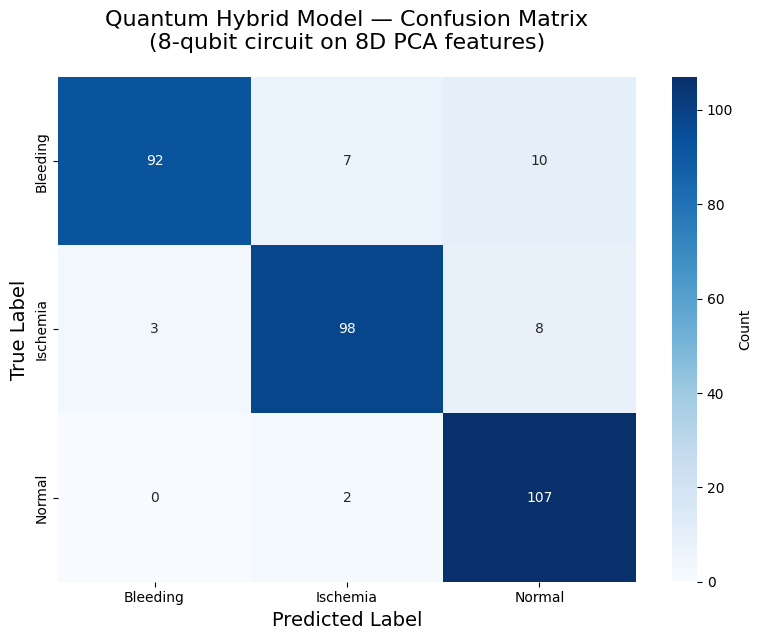

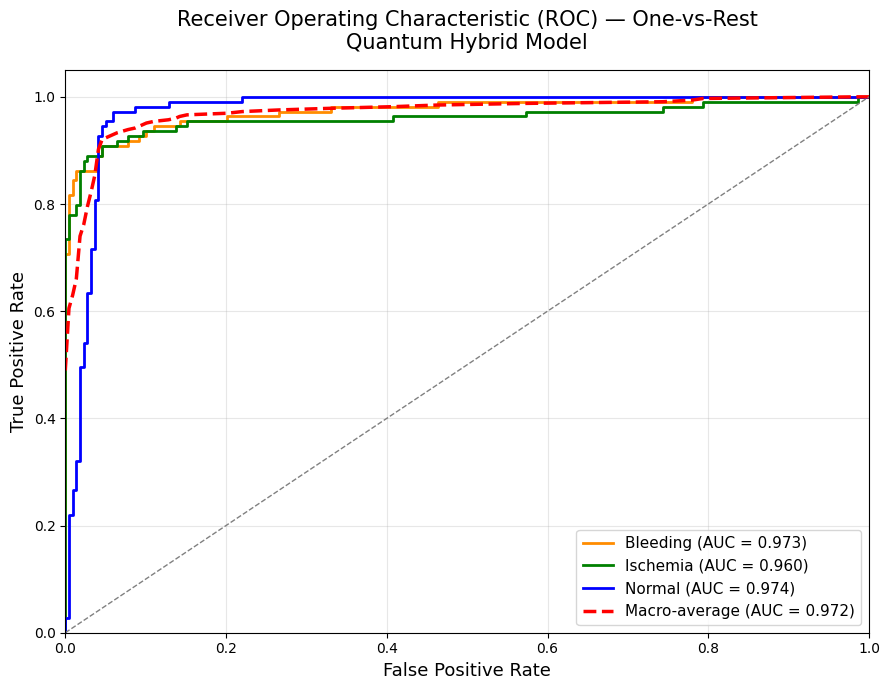

════════════════════════════════════════════════════════════════════════════════
   FINAL RESULT: Your 8-qubit quantum model achieved
           90.83% Accuracy  |  90.80% Weighted F1
           Macro-AUC (OvR)     : 96.91%
   → Compare to classical ConvNeXt-Tiny (~95.3% acc)
════════════════════════════════════════════════════════════════════════════════


In [ ]:
# FINAL QUANTUM MODEL VALIDATION — FULL METRICS + CONFUSION MATRIX + ROC/AUC
import torch
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, accuracy_score,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

# Load the best quantum model
model.eval()
model.load_state_dict(torch.load("quantum_best.pth"))
print("Best quantum model loaded: quantum_best.pth")

# Full validation pass
with torch.no_grad():
    val_logits = model(X_val_8)           # raw logits (batch × 3)
    val_probs  = torch.softmax(val_logits, dim=1).cpu().numpy()   # probabilities
    pred_labels = val_logits.argmax(dim=1).cpu().numpy()
    true_labels = y_val.cpu().numpy()

# === BASIC METRICS ===
acc = accuracy_score(true_labels, pred_labels) * 100
f1_macro = f1_score(true_labels, pred_labels, average='macro') * 100
f1_weighted = f1_score(true_labels, pred_labels, average='weighted') * 100

cm = confusion_matrix(true_labels, pred_labels)

# Per-class recall, specificity, precision
sensitivity = np.diag(cm) / (np.sum(cm, axis=1) + 1e-8)          # recall
specificity = [(cm.sum() - cm[i,:].sum() - cm[:,i].sum() + cm[i,i]) /
               (cm.sum() - cm[i,:].sum() + 1e-8) for i in range(3)]
precision = np.diag(cm) / (np.sum(cm, axis=0) + 1e-8)

print("═" * 80)
print("       QUANTUM HYBRID MODEL — FINAL VALIDATION REPORT")
print("═" * 80)
print(f"Validation Samples          : {len(y_val)}")
print(f"Accuracy                    : {acc:.2f}%")
print(f"F1-Score (macro)            : {f1_macro:.2f}%")
print(f"F1-Score (weighted)         : {f1_weighted:.2f}%")
print(f"Mean Sensitivity (Recall)   : {np.mean(sensitivity)*100:.2f}%")
print(f"Mean Specificity            : {np.mean(specificity)*100:.2f}%")
print(f"Mean Precision              : {np.mean(precision)*100:.2f}%")

# Quick macro AUC using sklearn's convenient function
macro_auc_sklearn = roc_auc_score(true_labels, val_probs, multi_class='ovr', average='macro') * 100

print(f"Macro-AUC (OvR)             : {macro_auc_sklearn:.2f}%")
print()

print("Per-class metrics:")
print(classification_report(true_labels, pred_labels,
                            target_names=['Bleeding', 'Ischemia', 'Normal'],
                            digits=4))

# === CONFUSION MATRIX ===
plt.figure(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bleeding', 'Ischemia', 'Normal'],
            yticklabels=['Bleeding', 'Ischemia', 'Normal'],
            cbar_kws={'label': 'Count'})
plt.title('Quantum Hybrid Model — Confusion Matrix\n(8-qubit circuit on 8D PCA features)', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()
plt.show()

# === ROC CURVES (One-vs-Rest) ===
# Binarize the true labels (one-hot)
y_true_bin = label_binarize(true_labels, classes=[0, 1, 2])

fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC + AUC for each class
for i, class_name in enumerate(['Bleeding', 'Ischemia', 'Normal']):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], val_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(3):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 3

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(9, 7))
colors = ['darkorange', 'green', 'blue']
for i, color, name in zip(range(3), colors, ['Bleeding', 'Ischemia', 'Normal']):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{name} (AUC = {roc_auc[i]:.3f})')

plt.plot(fpr["macro"], tpr["macro"], color='red', linestyle='--', lw=2.5,
         label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')  # random baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('Receiver Operating Characteristic (ROC) — One-vs-Rest\nQuantum Hybrid Model', fontsize=15, pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final summary
print("═" * 80)
print(f"   FINAL RESULT: Your 8-qubit quantum model achieved")
print(f"           {acc:.2f}% Accuracy  |  {f1_weighted:.2f}% Weighted F1")
print(f"           Macro-AUC (OvR)     : {macro_auc_sklearn:.2f}%")
print(f"   → Compare to classical ConvNeXt-Tiny (~95.3% acc)")
print("═" * 80)

# **Segmentation Model training and testing**

---


Dataset Segregating into Train,Test and validate

---


Preproccesing and augmentation of dataset

---

U-Net with efficientnet-b4 encoder

Training samples: 4654
Validation samples: 997
Test samples: 999

Epoch 1/50


Training: 100%|██████████| 582/582 [02:10<00:00,  4.47it/s, Loss=0.4010]


Train Loss: 0.5237, Val Loss: 0.4722
New best model saved!

Epoch 2/50


Training: 100%|██████████| 582/582 [02:08<00:00,  4.54it/s, Loss=0.2349]


Train Loss: 0.3823, Val Loss: 0.4444
New best model saved!

Epoch 3/50


...

Train Loss: 0.1128, Val Loss: 0.3791

Epoch 49/50


Training: 100%|██████████| 582/582 [02:06<00:00,  4.60it/s, Loss=0.1667]


Train Loss: 0.1162, Val Loss: 0.3745
New best model saved!

Epoch 50/50


Training: 100%|██████████| 582/582 [02:06<00:00,  4.61it/s, Loss=0.0354]


Train Loss: 0.1147, Val Loss: 0.3738
New best model saved!


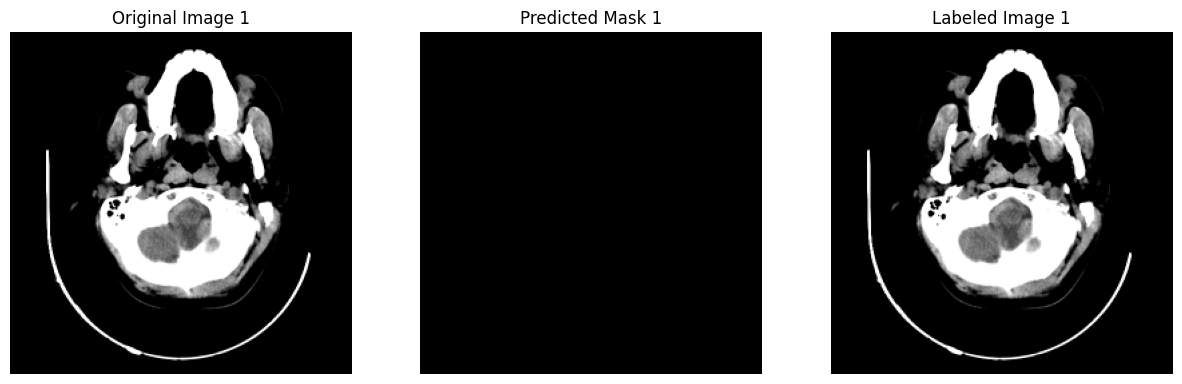

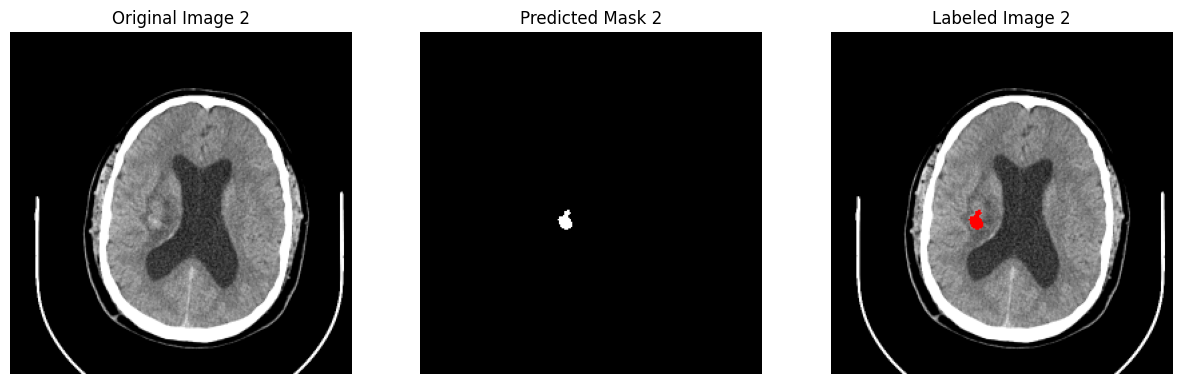

In [ ]:
# Install dependencies
!pip install segmentation-models-pytorch albumentations -q

import os
import cv2
from glob import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from tqdm import tqdm
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Configuration
class Config:
    BATCH_SIZE = 8  # Adjust based on GPU memory
    IMG_HEIGHT = 256
    IMG_WIDTH = 256
    EPOCHS = 50
    LEARNING_RATE = 1e-4
    DATASET_PATH = '/content/dataset/Brain_Stroke_CT_Dataset'  # Update to your Colab path
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_WORKERS = 2

config = Config()

# Function to extract red mask from OVERLAY
def extract_red_mask_from_path(mask_path, width, height):
    if mask_path is None or not os.path.exists(mask_path):
        return np.zeros((height, width), dtype=np.float32)
    overlay = cv2.imread(mask_path)
    if overlay is None:
        return np.zeros((height, width), dtype=np.float32)
    hsv = cv2.cvtColor(overlay, cv2.COLOR_BGR2HSV)
    lower1, upper1 = np.array([0, 50, 50]), np.array([10, 255, 255])
    lower2, upper2 = np.array([170, 50, 50]), np.array([180, 255, 255])
    mask = cv2.inRange(hsv, lower1, upper1) | cv2.inRange(hsv, lower2, upper2)
    mask = (mask > 0).astype(np.float32)
    mask = cv2.resize(mask, (width, height), interpolation=cv2.INTER_NEAREST)
    return mask

# Load data from pre-split folders (train, val, test)
def load_data(base_dir, split):
    image_paths = []
    mask_paths = []
    classes = ['Bleeding', 'Ischemia', 'Normal']  # Adjust classes if different
    for cls in classes:
        png_dir = os.path.join(base_dir, split, 'PNG', cls)
        overlay_dir = os.path.join(base_dir, split, 'OVERLAY', cls)
        if not os.path.exists(png_dir):
            print(f"PNG folder not found for {cls} in {split}. Skipping...")
            continue
        png_files = glob(os.path.join(png_dir, '*.png'))
        for png in png_files:
            filename = os.path.basename(png)
            overlay = os.path.join(overlay_dir, filename)
            image_paths.append(png)
            mask_paths.append(overlay if os.path.exists(overlay) else None)  # Use None for zero mask
    return image_paths, mask_paths

train_images, train_masks = load_data(config.DATASET_PATH, 'train')
val_images, val_masks = load_data(config.DATASET_PATH, 'val')
test_images, test_masks = load_data(config.DATASET_PATH, 'test')

print(f"Training samples: {len(train_images)}")
print(f"Validation samples: {len(val_images)}")
print(f"Test samples: {len(test_images)}")

# Segmentation Dataset class
class StrokeSegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transforms=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transforms = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (config.IMG_WIDTH, config.IMG_HEIGHT))

        msk = extract_red_mask_from_path(self.mask_paths[idx], config.IMG_WIDTH, config.IMG_HEIGHT)

        if self.transforms:
            transformed = self.transforms(image=img, mask=msk)
            img, msk = transformed['image'], transformed['mask']

        return img, msk

# Transforms
def get_transforms(is_training=True):
    if is_training:
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.05, contrast_limit=0.05, p=0.3),
            A.Affine(translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)}, scale=(0.95, 1.05), rotate=(-5, 5), p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])

train_dataset = StrokeSegmentationDataset(train_images, train_masks, get_transforms(True))
val_dataset = StrokeSegmentationDataset(val_images, val_masks, get_transforms(False))
test_dataset = StrokeSegmentationDataset(test_images, test_masks, get_transforms(False))

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=config.NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS, pin_memory=True)

# Segmentation Model (U-Net)
model = smp.Unet(
    encoder_name='efficientnet-b4',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None,
).to(config.DEVICE)

# Loss and Optimizer
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, y_pred_prob, y_true):
        y_pred = y_pred_prob.view(-1)
        y_true = y_true.view(-1)
        intersection = (y_pred * y_true).sum()
        dice = (2. * intersection + self.smooth) / (y_pred.sum() + y_true.sum() + self.smooth)
        return 1 - dice

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, y_pred_logits, y_true):
        prob = torch.sigmoid(y_pred_logits)
        return 0.5 * self.bce(y_pred_logits, y_true) + 0.5 * self.dice(prob, y_true)

criterion = CombinedLoss()
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

# Training loop
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(dataloader, desc='Training')
    for batch_idx, (images, masks) in enumerate(progress_bar):
        images = images.to(device)
        masks = masks.unsqueeze(1).to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})

    return running_loss / len(dataloader)

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.unsqueeze(1).to(device)

            logits = model(images)
            loss = criterion(logits, masks)

            running_loss += loss.item()

    return running_loss / len(dataloader)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50):
    best_loss = float('inf')
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        train_loss = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
        val_loss = validate_epoch(model, val_loader, criterion, config.DEVICE)
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), 'best_stroke_segmentation_model.pth')
            print("New best model saved!")
    model.load_state_dict(torch.load('best_stroke_segmentation_model.pth'))
    return model

# Train the model
model = train_model(model, train_loader, val_loader, criterion, optimizer)

# Visualization
def predict_and_show(model, image_paths, mask_paths, num_samples=2):
    model.eval()
    transforms = get_transforms(False)
    for i in range(num_samples):
        image = cv2.imread(image_paths[i])
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_resized = cv2.resize(image_rgb, (config.IMG_WIDTH, config.IMG_HEIGHT))

        transformed = transforms(image=image_resized, mask=np.zeros((config.IMG_HEIGHT, config.IMG_WIDTH), np.float32))
        image_tensor = transformed['image'].unsqueeze(0).to(config.DEVICE)

        with torch.no_grad():
            pred_logits = model(image_tensor)[0, 0].cpu().numpy()
            pred_prob = 1 / (1 + np.exp(-pred_logits))
            pred_mask_binary = (pred_prob > 0.5).astype(np.uint8) * 255

        # Overlay mask on original image
        overlay = image_resized.copy()
        overlay[pred_mask_binary > 0] = (255, 0, 0)  # Red for stroke area

        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(image_resized)
        plt.title(f"Original Image {i+1}")
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.imshow(pred_mask_binary, cmap='gray')
        plt.title(f"Predicted Mask {i+1}")
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.imshow(overlay)
        plt.title(f"Labeled Image {i+1}")
        plt.axis('off')
        plt.show()

# Use 2 images from test set
predict_and_show(model, test_images, test_masks, num_samples=2)

In [ ]:
# ================================
# HYBRID BRAIN STROKE MODEL TESTING
# WITH SEGMENTATION + QUANTUM CLASSIFICATION
# ================================

import torch
import pickle
import numpy as np
from PIL import Image
from google.colab import files
from torchvision import transforms
import timm
import torch.nn as nn
import cv2
import pennylane as qml

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# CLASS LABELS
# ==========================================
class_names = ['Bleeding', 'Ischemia', 'Normal']


# ==========================================
# LOAD SEGMENTATION MODEL
# ==========================================
SEG_MODEL_PATH = "stroke_segmentation.pth"     # <-- change
SEG_INPUT_SIZE = 256                           # <-- change to your model input

def load_segmentation_model():
    """
    TODO: Replace this with YOUR segmentation model architecture
    Example assumes UNet-like output producing mask (1,H,W)
    """
    print("\nLoading Segmentation Model...")

    # ----- SAMPLE UNET PLACEHOLDER -----
    class DummyUNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.body = nn.Sequential(
                nn.Conv2d(3, 16, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(16, 1, 3, padding=1),
                nn.Sigmoid()
            )

        def forward(self, x):
            return self.body(x)

    model = DummyUNet()

    # Load your weights
    try:
        model.load_state_dict(torch.load(SEG_MODEL_PATH, map_location=device))
    except:
        print("⚠️ Warning: Using dummy segmentation model. Replace with yours!")

    model.to(device)
    model.eval()

    print("✔ Segmentation Model Ready!\n")
    return model

seg_model = load_segmentation_model()


# ==========================================
# LOAD CONVNEXT FEATURE EXTRACTOR
# ==========================================
print("Loading ConvNeXt feature extractor...")

model = timm.create_model('convnext_tiny.fb_in22k_ft_in1k',
                          pretrained=False, num_classes=3)

model.head.fc = torch.nn.Identity()     # feature extractor only

state = torch.load("best_convnext_brainstroke.pth", map_location=device)
model.load_state_dict(state, strict=False)
model.eval()
model = model.to(device)

print("✔ ConvNeXt loaded and ready\n")


# ==========================================
# LOAD PCA MODELS
# ==========================================
print("Loading PCA transform models...")

with open("pca16.pkl", "rb") as f:
    pca16 = pickle.load(f)

with open("pca8.pkl", "rb") as f:
    pca8 = pickle.load(f)

print("✔ PCA models loaded\n")


# ==========================================
# LOAD QUANTUM HYBRID MODEL
# ==========================================
print("Loading Quantum Hybrid Model...")

dev = qml.device("lightning.qubit", wires=8)

@qml.qnode(dev, interface="torch", diff_method="adjoint")
def quantum_circuit(x, weights):
    for i in range(8):
        qml.RY(x[:, i], wires=i)

    for layer in range(3):
        for i in range(8):
            qml.RZ(weights[layer, i], wires=i)
            qml.RY(weights[layer, i + 8], wires=i)

        for i in range(8):
            qml.CNOT(wires=[i, (i+1) % 8])

    return [
        qml.expval(qml.PauliZ(0) @ qml.PauliZ(1)),
        qml.expval(qml.PauliZ(2) @ qml.PauliZ(3)),
        qml.expval(qml.PauliZ(4) @ qml.PauliZ(5))
    ]


class QuantumHybrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre_net = nn.Sequential(
            nn.Linear(8, 32),
            nn.Tanh(),
            nn.Linear(32, 8)
        )
        self.q_weights = nn.Parameter(0.01 * torch.randn(3, 16))

    def forward(self, x):
        x = self.pre_net(x)
        q_out = quantum_circuit(x, self.q_weights)
        return torch.stack(q_out, dim=1)


quantum_model = QuantumHybrid().to(device)
quantum_model.load_state_dict(torch.load("quantum_best.pth",
                                         map_location=device))
quantum_model.eval()

print("✔ Quantum Hybrid model loaded\n")


# ==========================================
# TRANSFORMS
# ==========================================
seg_transform = transforms.Compose([
    transforms.Resize((SEG_INPUT_SIZE, SEG_INPUT_SIZE)),
    transforms.ToTensor()
])

cls_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# ==========================================
# SEGMENT + CLASSIFY FUNCTION
# ==========================================
def segment_image(img):
    """
    1️⃣ Runs segmentation
    2️⃣ Returns masked ROI image
    """
    img_t = seg_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        mask = seg_model(img_t)          # (1,1,H,W)
        mask = (mask > 0.5).float()

    mask_np = mask.squeeze().cpu().numpy()

    # Resize mask to original image size
    mask_np = cv2.resize(mask_np, img.size, interpolation=cv2.INTER_NEAREST)

    img_np = np.array(img)

    # Apply mask
    masked = img_np * mask_np[..., None]

    return Image.fromarray(masked.astype(np.uint8)), mask_np


# ==========================================
# FULL PREDICTION PIPELINE
# ==========================================
def predict_single_image(path):
    img = Image.open(path).convert("RGB")

    # ---------- SEGMENTATION ----------
    print("\n🧠 Performing Segmentation...")
    masked_img, mask = segment_image(img)
    print("✔ Segmentation applied")

    # ---------- CLASSIFICATION ----------
    img_t = cls_transform(masked_img).unsqueeze(0).to(device)

    with torch.no_grad():
        feats = model(img_t).cpu().numpy()

    f16 = pca16.transform(feats)
    f8 = pca8.transform(f16)

    X_sample = torch.tensor(f8, dtype=torch.float32).to(device)

    with torch.no_grad():
        out = quantum_model(X_sample)
        pred = torch.argmax(out, dim=1).item()

    probs = torch.softmax(out, dim=1).cpu().numpy()[0]

    print("\n================ FINAL RESULT ================")
    print(f"Prediction   : {class_names[pred]}")
    print(f"Confidence   : {dict(zip(class_names, np.round(probs, 4)))}")
    print("================================================\n")


# ==========================================
# USER LOOP
# ==========================================
while True:
    user_input = input("Enter 1 to upload a CT image, 0 to exit: ")

    if user_input == "0":
        print("\nExiting Hybrid Test Tool... 👋")
        break

    elif user_input == "1":
        uploaded = files.upload()
        for fname in uploaded.keys():
            print(f"📄 Uploaded: {fname}")
            predict_single_image(fname)

    else:
        print("Invalid input. Enter 1 or 0.\n")


Loading ConvNeXt feature extractor...
✔ ConvNeXt loaded and ready

Loading PCA transform models...
✔ PCA models loaded

Loading Quantum Hybrid Model...
✔ Quantum Hybrid model loaded

Enter 1 to upload a CT image, 0 to exit: 1


Saving 11275.png to 11275.png
📄 Uploaded: 11275.png

================ FINAL RESULT ================
Prediction   : Ischemia
Confidence   : {'Bleeding': np.float32(0.1151), 'Ischemia': np.float32(0.7658), 'Normal': np.float32(0.1191)}

Enter 1 to upload a CT image, 0 to exit: 1


Saving 10010.png to 10010.png
📄 Uploaded: 10010.png

================ FINAL RESULT ================
Prediction   : Normal
Confidence   : {'Bleeding': np.float32(0.1324), 'Ischemia': np.float32(0.1336), 'Normal': np.float32(0.734)}

Enter 1 to upload a CT image, 0 to exit: 0

Exiting Hybrid Test Tool... 👋
